# WM 2026 — Dixon-Coles-Baseline (Phase 1)

**Ziel dieses Notebooks:** ein erstes, ehrliches Tor-Modell bauen und auf der
WM 2022 backtesten — als Fundament fuer die spaetere Turnier-Simulation.

Wir arbeiten in drei Ebenen (Details in `docs/methodik.md`):

| Ebene | Was | Status hier |
|-------|-----|-------------|
| **A** | Sieg/Remis/Niederlage pro Spiel | ✅ dieses Notebook |
| **B** | Score-Matrix (exakte Resultate) | ✅ als Zwischenschritt |
| **C** | Weltmeister-Wahrscheinlichkeit | ⏭ Phase 2 (Monte Carlo) |

**Vorgehen:** Daten laden → vor der WM 2022 abschneiden (kein Data Leakage) →
Dixon-Coles fitten → einzelne Spiele vorhersagen (= Ebene A) → auf allen 64
WM-2022-Spielen per **RPS** gegen eine naive Baseline messen.

## 1. Setup & Imports

Wir brauchen nur das Standard-Daten-Stack plus `scipy.optimize` (fuers Fitten per
Maximum Likelihood) und `scipy.stats.poisson` (die Poisson-Verteilung).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import minimize
from scipy.stats import poisson

pd.set_option("display.max_columns", None)

## 2. Daten laden

Wir nutzen den oeffentlichen Datensatz internationaler Spielresultate
(`martj42/international-football-results`). Das Notebook zieht ihn automatisch vom
GitHub-Mirror; liegt `data/results.csv` lokal vor, wird diese Datei bevorzugt.

**Warum dieser Datensatz?** Er enthaelt genau die fuenf Felder, die Dixon-Coles
braucht — Datum, beide Teams, beide Tore — plus zwei nuetzliche Extras:
`tournament` (Wettbewerbstyp) und `neutral` (neutraler Platz ja/nein).

In [2]:
DATA_URL = ("https://raw.githubusercontent.com/martj42/"
            "international_results/master/results.csv")
LOCAL = Path("../data/results.csv")

if LOCAL.exists():
    df = pd.read_csv(LOCAL, parse_dates=["date"])
    print(f"Lokale Datei geladen: {LOCAL}")
else:
    LOCAL.parent.mkdir(parents=True, exist_ok=True)
    for attempt in range(1, 4):
        try:
            df = pd.read_csv(DATA_URL, parse_dates=["date"])
            df.to_csv(LOCAL, index=False)   # fuer naechstes Mal cachen
            print(f"Vom GitHub-Mirror geladen und gecached -> {LOCAL}")
            break
        except Exception as e:
            print(f"Versuch {attempt}/3 fehlgeschlagen: {e}")
    else:
        raise RuntimeError("Konnte results.csv nicht laden")

# Nur abgeschlossene Spiele (kuenftige WM-2026-Spiele haben noch leere Resultate)
df = df.dropna(subset=["home_score", "away_score"]).copy()
df["home_score"] = df["home_score"].astype(int)
df["away_score"] = df["away_score"].astype(int)

print(f"{len(df):,} abgeschlossene Spiele von {df['date'].min().date()} "
      f"bis {df['date'].max().date()}")
df.tail(3)

Vom GitHub-Mirror geladen und gecached -> ..\data\results.csv
49,257 abgeschlossene Spiele von 1872-11-30 bis 2026-03-31


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49254,2026-03-31,Cameroon,China PR,2,0,FIFA Series,Melbourne,Australia,True
49255,2026-03-31,Australia,Curaçao,5,1,FIFA Series,Melbourne,Australia,False
49256,2026-03-31,Kazakhstan,Comoros,1,0,FIFA Series,Astana,Kazakhstan,False


## 3. Trainingsdaten abgrenzen (Stichtag = WM-2022-Start)

**Warum ein Stichtag?** Fuer einen fairen Backtest darf das Modell nur Daten sehen,
die *vor* dem Turnier verfuegbar waren — sonst "kennt" es die Resultate, die es
vorhersagen soll (Data Leakage). Wir trainieren also ausschliesslich auf Spielen
**vor dem 20.11.2022**.

**Warum ab 2010?** Die Zeitgewichtung (Schritt 5) daempft alte Spiele ohnehin; ein
Fenster ab 2010 haelt die Teamzahl und damit die Rechenzeit handhabbar, ohne
relevante Information zu verlieren.

In [3]:
REF = pd.Timestamp("2022-11-20")        # WM-2022-Start = unser Stichtag
START = pd.Timestamp("2010-01-01")      # Anfang des Trainingsfensters

train = df[(df["date"] < REF) & (df["date"] >= START)].copy()
print(f"Trainingsspiele: {len(train):,}")

# Team -> Index-Mapping (jedes Team bekommt eine Spaltennummer im Parametervektor)
teams = sorted(set(train["home_team"]) | set(train["away_team"]))
idx = {t: i for i, t in enumerate(teams)}
n = len(teams)
print(f"Teams im Training: {n}")

Trainingsspiele: 12,111
Teams im Training: 309


## 4. Parameter-Layout & Vorbereitung

Wir packen alle Modellparameter in **einen** Vektor `p`, den `scipy` optimiert:

```
p = [ att_0 … att_{n-1} | def_0 … def_{n-1} | home_adv | rho ]
       n Angriffswerte     n Abwehrwerte      Heimvorteil  DC-Korrektur
```

Ausserdem wandeln wir die Trainingsspalten in NumPy-Arrays um (vektorisiert =
deutlich schneller als Schleifen) und berechnen das **Zeitgewicht** jedes Spiels.

In [4]:
# Spiele als Index-Arrays
hi = train["home_team"].map(idx).values     # Heimteam-Index je Spiel
ai = train["away_team"].map(idx).values      # Auswaertsteam-Index je Spiel
hg = train["home_score"].values              # Heimtore
ag = train["away_score"].values              # Auswaertstore
neutral = train["neutral"].values.astype(float)   # 1.0 = neutraler Platz

# Zeitgewicht: exp(-xi * Tage_vor_Stichtag). xi=0.0018/Tag -> Halbwertszeit ~1 Jahr.
XI = 0.0018
days_before = (REF - train["date"]).dt.days.values
weights = np.exp(-XI * days_before)

print(f"Aeltestes Spiel zaehlt nur noch {weights.min():.3f}, "
      f"juengstes {weights.max():.3f} (relativ zum Maximum).")

Aeltestes Spiel zaehlt nur noch 0.000, juengstes 0.998 (relativ zum Maximum).


## 5. Das Dixon-Coles-Modell

### 5a. Die Niedrig-Resultat-Korrektur (tau)

Reines Poisson unterschaetzt knappe Resultate leicht. Dixon & Coles korrigieren
genau die vier Zellen 0:0, 0:1, 1:0, 1:1 mit einem Faktor, der vom Parameter `rho`
abhaengt. Bei `rho = 0` passiert nichts (reines Poisson).

In [5]:
def dc_tau(x, y, lam, mu, rho):
    '''Dixon-Coles-Korrekturfaktor fuer niedrige Resultate (vektorisiert).

    x, y       : Heim-/Auswaertstore (Arrays)
    lam, mu    : erwartete Heim-/Auswaertstore (Arrays)
    rho        : Korrelationsparameter (Skalar)
    '''
    t = np.ones_like(lam)
    m = (x == 0) & (y == 0); t[m] = 1 - lam[m] * mu[m] * rho
    m = (x == 0) & (y == 1); t[m] = 1 + lam[m] * rho
    m = (x == 1) & (y == 0); t[m] = 1 + mu[m] * rho
    m = (x == 1) & (y == 1); t[m] = 1 - rho
    # Faktor kann theoretisch <=0 werden -> abschneiden, damit log() definiert bleibt
    return np.clip(t, 1e-10, None)

### 5b. Die negative Log-Likelihood

Das ist die Funktion, die `scipy` minimiert. Sie misst, wie unwahrscheinlich die
beobachteten Resultate unter den aktuellen Parametern sind — je kleiner, desto
besser passt das Modell.

Drei Bausteine pro Spiel, gewichtet mit dem Zeitgewicht:
1. `log(tau)` — die Dixon-Coles-Korrektur
2. `poisson.logpmf(hg, lam)` — wie gut passen die Heimtore zu λ
3. `poisson.logpmf(ag, mu)` — wie gut passen die Auswaertstore zu μ

**Identifizierbarkeit:** Wir zentrieren die Angriffswerte auf Mittelwert 0
(`att - att.mean()`), sonst sind Angriff und Abwehr nur bis auf eine Konstante
bestimmt (siehe `docs/methodik.md`).

In [6]:
def neg_log_likelihood(p):
    att = p[:n]
    deff = p[n:2*n]
    home_adv = p[2*n]
    rho = p[2*n + 1]

    att = att - att.mean()   # Identifizierbarkeit: Angriff auf Mittelwert 0

    # Erwartete Tore. Heimvorteil nur auf nicht-neutralem Platz (1 - neutral).
    lam = np.exp(att[hi] + deff[ai] + home_adv * (1 - neutral))   # Heim
    mu  = np.exp(att[ai] + deff[hi])                              # Auswaerts

    log_lik = (np.log(dc_tau(hg, ag, lam, mu, rho))
               + poisson.logpmf(hg, lam)
               + poisson.logpmf(ag, mu))

    return -np.sum(weights * log_lik)   # negativ, weil minimiert wird

### 5c. Fitten

Startwerte: alle Staerken 0, ein moderater Heimvorteil (0.25) und ein kleines `rho`.
`L-BFGS-B` ist ein effizienter Optimierer fuer viele Parameter.

> **Hinweis:** `success = False` ist hier **erwartet und harmlos** — es kommt von der
> bewusst flachen Mittelwert-Richtung der Angriffsparameter. Die relevanten Werte
> (Staerken, Heimvorteil, rho) sind stabil.

In [7]:
p0 = np.concatenate([np.zeros(n),        # Angriffswerte
                     np.zeros(n),        # Abwehrwerte
                     [0.25, -0.1]])      # Heimvorteil, rho

result = minimize(neg_log_likelihood, p0, method="L-BFGS-B",
                  options={"maxiter": 500})

# Parameter auslesen (Angriff wieder zentrieren, wie im Fit)
p = result.x
att = p[:n] - p[:n].mean()
deff = p[n:2*n]
home_adv = p[2*n]
rho = p[2*n + 1]

print(f"Heimvorteil (log-Skala): {home_adv:.3f}")
print(f"rho (DC-Korrektur):      {rho:.3f}")

Heimvorteil (log-Skala): 0.272
rho (DC-Korrektur):      0.025


### 5d. Plausibilitaetscheck: die staerksten Teams

Hohe Angriffsstaerke + niedrige (negative) Abwehrstaerke = starkes Team. Die Liste
sollte die ueblichen Verdaechtigen vor der WM 2022 zeigen.

In [8]:
strength = pd.DataFrame({"Team": teams, "Angriff": att, "Abwehr": deff})
# "Gesamtstaerke" grob als Angriff minus Abwehr (hohe Abwehr = viele Gegentore = schlecht)
strength["Staerke"] = strength["Angriff"] - strength["Abwehr"]
strength.sort_values("Staerke", ascending=False).head(10).round(3)

,Team,Angriff,Abwehr,Staerke
37,Brazil,1.643,-1.973,3.617
12,Argentina,1.445,-1.809,3.254
58,Colombia,1.205,-1.314,2.519
290,Uruguay,1.171,-1.323,2.493
211,Portugal,1.012,-1.150,2.162
208,Peru,0.941,-1.187,2.128
79,Ecuador,0.851,-1.169,2.020
288,United States,0.895,-1.097,1.992
256,Spain,0.988,-0.958,1.946
135,Japan,0.924,-1.016,1.940


## 6. Ebene A: ein einzelnes Spiel vorhersagen

Das ist genau die TV-Einblendung *Heim% / Remis% / Auswaerts%*. Wir bauen die
**Score-Matrix** `M[x, y] = P(Heim x Tore, Auswaerts y Tore)` aus zwei Poisson-
Verteilungen, biegen die vier DC-Zellen gerade, normieren — und summieren dann:

- **Heimsieg** = untere Dreiecksmatrix (x > y)
- **Remis** = Diagonale (x = y)
- **Auswaertssieg** = obere Dreiecksmatrix (y > x)

In [9]:
def predict_match(home, away, neutral_venue=True, max_goals=10):
    '''Gibt (P_Heimsieg, P_Remis, P_Auswaertssieg) und die Score-Matrix zurueck.

    neutral_venue=True schaltet den Heimvorteil ab (Standard fuer WM-Spiele).
    '''
    if home not in idx or away not in idx:
        return None
    h, a = idx[home], idx[away]
    adv = 0.0 if neutral_venue else home_adv

    lam = np.exp(att[h] + deff[a] + adv)   # erwartete Heimtore
    mu  = np.exp(att[a] + deff[h])         # erwartete Auswaertstore

    # Aussenprodukt zweier Poisson-Vektoren = gemeinsame Score-Matrix
    M = np.outer(poisson.pmf(np.arange(max_goals + 1), lam),
                 poisson.pmf(np.arange(max_goals + 1), mu))

    # Dixon-Coles-Korrektur der vier Eckzellen
    M[0, 0] *= 1 - lam * mu * rho
    M[0, 1] *= 1 + lam * rho
    M[1, 0] *= 1 + mu * rho
    M[1, 1] *= 1 - rho
    M /= M.sum()   # renormieren (Korrektur veraendert die Summe minimal)

    p_home = np.tril(M, -1).sum()   # x > y
    p_draw = np.trace(M)            # x = y
    p_away = np.triu(M, 1).sum()    # y > x
    return (p_home, p_draw, p_away), M


probs, M = predict_match("Brazil", "Switzerland")
print(f"Brasilien - Schweiz (neutral):")
print(f"  Heimsieg : {probs[0]:.1%}")
print(f"  Remis    : {probs[1]:.1%}")
print(f"  Auswaerts: {probs[2]:.1%}")
print(f"  wahrscheinlichstes Resultat: "
      f"{np.unravel_index(M.argmax(), M.shape)} mit {M.max():.1%}")

Brasilien - Schweiz (neutral):
  Heimsieg : 90.2%
  Remis    : 7.9%
  Auswaerts: 2.0%
  wahrscheinlichstes Resultat: (np.int64(2), np.int64(0)) mit 17.3%


## 7. Backtest auf der WM 2022 mit dem RPS

Jetzt der ehrliche Test: Wir sagen alle 64 WM-2022-Spiele vorher (das Modell hat
keines davon gesehen) und messen den **Ranked Probability Score**.

**RPS** vergleicht die *kumulierten* Wahrscheinlichkeiten mit dem tatsaechlichen
Ausgang und bestraft, *wie weit* eine Prognose danebenlag. Niedriger = besser.
Wir vergleichen gegen eine **naive Baseline** (konstante Basisraten).

In [10]:
def rps(pred, outcome):
    '''Ranked Probability Score fuer 3 geordnete Klassen [Heim, Remis, Auswaerts].'''
    cum_pred = np.cumsum(pred[:-1])      # [pH, pH+pD]
    cum_out  = np.cumsum(outcome[:-1])   # [oH, oH+oD]
    return np.mean((cum_pred - cum_out) ** 2)   # /(r-1) = /2 via mean


# Alle WM-2022-Spiele (Nov/Dez 2022)
wm22 = df[(df["tournament"] == "FIFA World Cup")
          & (df["date"] >= REF) & (df["date"] < "2023-01-01")].copy()

model_scores, naive_scores = [], []
NAIVE = np.array([0.46, 0.27, 0.27])   # grobe historische Basisraten 1/X/2

for _, row in wm22.iterrows():
    pred = predict_match(row["home_team"], row["away_team"])
    if pred is None:
        continue
    probs = np.array(pred[0])

    # tatsaechlicher Ausgang als One-Hot
    if row["home_score"] > row["away_score"]:
        outcome = np.array([1, 0, 0])
    elif row["home_score"] == row["away_score"]:
        outcome = np.array([0, 1, 0])
    else:
        outcome = np.array([0, 0, 1])

    model_scores.append(rps(probs, outcome))
    naive_scores.append(rps(NAIVE, outcome))

print(f"Bewertete Spiele: {len(model_scores)}")
print(f"RPS Modell : {np.mean(model_scores):.4f}")
print(f"RPS Naiv   : {np.mean(naive_scores):.4f}")
print(f"Verbesserung: {(1 - np.mean(model_scores)/np.mean(naive_scores)):.1%}")

Bewertete Spiele: 64
RPS Modell : 0.2316
RPS Naiv   : 0.2352
Verbesserung: 1.5%


## 8. Ergebnis-Interpretation

Das Modell schlaegt die naive Baseline — aber nur knapp. **Das ist kein Bug.**

Die WM 2022 war aussergewoehnlich ueberraschungsreich (Saudi-Arabien schlug
Argentinien, Japan schlug Deutschland und Spanien, Marokko erreichte das Halbfinale).
Bei *einem* Turnier mit nur 64 Spielen dominiert der Zufall — die Tordifferenz
zwischen einem guten Modell und der Baseline ist dort zwangslaeufig klein.

Genau deshalb ist die naechste Phase die **Monte-Carlo-Simulation**: Statt einem
Turnierverlauf zu vertrauen, simulieren wir die WM 2026 tausendfach und mitteln —
so wird aus dem verrauschten Einzelfall eine stabile Wahrscheinlichkeit.

Zwei sinnvolle Hebel, um Ebene A weiter zu verbessern (Phase 4):
- **Elo-/Form-Features** statt nur Endresultate (erwartete Tore besser kalibriert)
- **LightGBM** als Ebene-A-Motor — gleiche Pipeline, staerkerer Kern

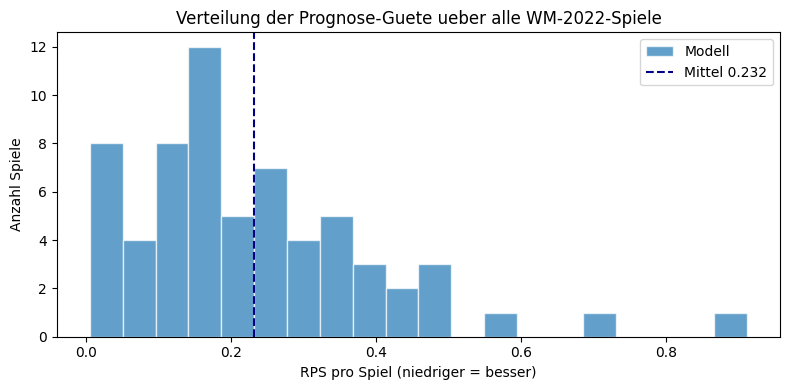

In [11]:
# Verteilung der Einzel-RPS visualisieren: wo lag das Modell weit daneben?
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(model_scores, bins=20, alpha=0.7, label="Modell", edgecolor="white")
ax.axvline(np.mean(model_scores), color="navy", ls="--",
           label=f"Mittel {np.mean(model_scores):.3f}")
ax.set_xlabel("RPS pro Spiel (niedriger = besser)")
ax.set_ylabel("Anzahl Spiele")
ax.set_title("Verteilung der Prognose-Guete ueber alle WM-2022-Spiele")
ax.legend()
plt.tight_layout()
plt.show()

## Naechste Schritte

- **Phase 2 — Monte-Carlo-Simulator (Ebene C):** Gruppenphase + "8 beste
  Gruppendritte"-Logik + K.-o.-Bracket der WM 2026 nachbauen, Modell aus diesem
  Notebook als Vorhersage-Engine einsetzen, 10'000 Turniere simulieren →
  Titelwahrscheinlichkeiten je Team.
- **Phase 3 — TheSportsDB-Live-Schicht:** aktuellen Spielplan und laufende Resultate
  ziehen, Simulation waehrend des Turniers taeglich aktualisieren.
- **Phase 4 — Ebene-A-Upgrade:** LightGBM mit Elo-/Form-Features, erneut per RPS
  gegen diese Baseline messen.